In [3]:
import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd  # To play sound in the notebook
import os # interface with underlying OS that python is running on
import sys
 
data = pd.read_csv('../ravdes/featureNormal_Ek.csv')

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,185,186,187,188,189,190,191,192,0.1,0.2
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,17.645388,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,17.582760,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,17.437520,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,16.492804,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,17.020093,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8


In [5]:
data.shape

(1440, 195)

In [28]:
df=data.loc[data.iloc[:,-2] == 0] #female
#ymale=data.loc[data.iloc[:,-2] == 1]

In [29]:
data.iloc[:,-2] == 0 #female

0       False
1       False
2       False
3       False
4       False
        ...  
1435     True
1436     True
1437     True
1438     True
1439     True
Name: 0.1, Length: 1440, dtype: bool

In [30]:
X=df.iloc[:,:-2].copy()
y=df.iloc[:,-1].copy()

In [31]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,15.032267,17.122944,17.137267,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,15.800671,16.939402,16.786359,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,15.484927,17.181703,18.043089,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,15.257555,16.719364,17.726324,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,16.251168,17.629721,16.558219,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [32]:
#y=y-1
y

60      1
61      1
62      1
63      1
64      2
       ..
1435    8
1436    8
1437    8
1438    8
1439    8
Name: 0.2, Length: 720, dtype: int64

In [33]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,15.032267,17.122944,17.137267,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,15.800671,16.939402,16.786359,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,15.484927,17.181703,18.043089,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,15.257555,16.719364,17.726324,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,16.251168,17.629721,16.558219,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [34]:
X.shape, y

((720, 193),
 60      1
 61      1
 62      1
 63      1
 64      2
        ..
 1435    8
 1436    8
 1437    8
 1438    8
 1439    8
 Name: 0.2, Length: 720, dtype: int64)

In [35]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [36]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [37]:
X.shape, y1.shape

((720, 193), (720, 8))

In [38]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,15.032267,17.122944,17.137267,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,15.800671,16.939402,16.786359,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,15.484927,17.181703,18.043089,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,15.257555,16.719364,17.726324,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,16.251168,17.629721,16.558219,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [17]:
#########fisher score

In [39]:
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [40]:
from skfeature.function.similarity_based import fisher_score
fisherindex = fisher_score.fisher_score(X2, y2, mode='index') 

In [41]:
selected_features=X2

In [42]:
selected_features, len(selected_features), selected_features[2]

(array([[-6.26065857e+02,  6.71292114e+01, -1.45061035e+01, ...,
         -6.04118939e-02,  1.11277537e-02,  4.89410764e-04],
        [-6.22978882e+02,  6.16102409e+01, -1.61552811e+01, ...,
         -2.46660189e-02,  1.16137510e-02, -8.25796356e-03],
        [-5.94977844e+02,  6.26938286e+01, -1.62577801e+01, ...,
         -4.41625957e-02,  2.31496611e-03, -1.37481262e-02],
        ...,
        [-5.17733276e+02,  4.04596329e+01, -2.72174416e+01, ...,
          9.17115917e-03,  7.20391375e-03,  1.32187741e-02],
        [-4.63998352e+02,  3.54969254e+01, -1.42607832e+01, ...,
         -6.00979537e-02,  5.99708470e-03, -9.21970305e-03],
        [-4.99242126e+02,  3.95404968e+01, -8.36169529e+00, ...,
         -5.17030715e-02, -1.03788114e-02,  1.78635145e-02]]),
 720,
 array([-5.94977844e+02,  6.26938286e+01, -1.62577801e+01,  9.05116081e+00,
        -9.17550945e+00, -2.49130145e-01, -9.89823627e+00, -7.67172241e+00,
        -8.78281879e+00,  4.26915050e-01, -8.10434246e+00, -1.27070701e

In [43]:
X3=pd.DataFrame(selected_features)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,15.032267,17.122944,17.137267,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489
1,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,15.800671,16.939402,16.786359,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258
2,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,15.484927,17.181703,18.043089,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748
3,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,15.257555,16.719364,17.726324,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018
4,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,16.251168,17.629721,16.558219,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
716,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
717,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
718,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [45]:
X.iloc[:,5:21]

,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
60,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,-7.912409,-0.210760,-7.740003,1.756948,-9.324497,-1.198008,-4.133364,-1.631853,-2.066447,-0.454988,-0.492106
61,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,-6.152109,-0.615899,-8.214749,1.275640,-8.237226,-2.645824,-3.443796,-0.612220,-2.490293,-0.452201,-0.757748
62,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,-8.104342,-1.270707,-9.362936,3.294116,-8.703416,-2.625140,-4.680979,-3.360180,-1.953824,0.267930,-0.405246
63,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,-9.551315,-1.466953,-12.188832,1.340084,-10.352579,-2.398706,-4.686605,-4.565247,-2.227786,-0.699804,-0.750733
64,2.161584,-7.936422,-4.958043,-6.853294,0.523445,-6.652872,-2.524537,-7.584999,3.084172,-8.050755,-1.479591,-4.934464,-1.571014,-5.846342,-1.533878,-2.314848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,-13.470782,-0.407410,-9.948418,5.518756,2.247648,1.531702,-2.982210,0.129457,-4.504814,1.020297,0.744685
1436,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,-14.131364,8.980473,-5.571723,2.803077,-0.283363,-2.442273,-3.839922,-1.522143,-2.926482,0.365428,-1.837317
1437,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,-11.430717,9.099095,-7.937002,1.855414,-1.323820,-2.413804,-1.276750,0.090517,-6.109476,3.518335,-0.603973
1438,0.799514,-18.052525,-4.351163,-7.299998,0.214021,-11.528538,1.779407,-12.382866,5.248011,-3.515553,-0.067374,-4.443567,4.867039,-2.615891,4.354655,6.432075


In [26]:
#########

In [46]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM
from keras.preprocessing.text import Tokenizer
#from keras.preprocessing.sequence import pad_sequences
from keras.utils.data_utils import pad_sequences

from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [47]:
### import random, numpy as np
from tensorflow.keras import optimizers

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score

#kfold=5 #by default
hist=[]
scores=[]
totalsize=X.shape[0]

kfold = StratifiedKFold(n_splits=5, shuffle=True,random_state=None)
cvscores = []
num=0
for train, test in kfold.split(X3,y):

    model_name = 'Femalemodel'+str(num)
    savedir='RAVDESS_Model100/'
    model_path = os.path.join(savedir, (model_name+'.h5'))
    
    x_traincnn =np.expand_dims(X.iloc[train], axis=2)
    x_testcnn= np.expand_dims(X.iloc[test], axis=2)
    
    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.legacy.RMSprop(learning_rate=0.00001, decay=1e-6)

    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    
    print(num,'\n')
    y_train=y1[train]
    y_test=y1[test]
    aa=m1.fit(x_traincnn, y_train, batch_size=64,  validation_data=(x_testcnn, y_test), epochs=700) #,epochs=300)
    hist.append(aa)
    scores.append(m1.evaluate(x_testcnn, y_test))
    
    #outfile = TemporaryFile()
    #with open(x_testcnn, 'wb') as f:
    np.save((savedir+'/X'+str(num)),x_testcnn)
    np.save((savedir+'/y'+str(num)),y_test)

    model_json = m1.to_json()
    with open((savedir+model_name+'.json'), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)
    num+=1

print(scores, np.mean(scores))

0 

Epoch 1/700
9/9 [==============================] - 2s 133ms/step - loss: 2.4086 - accuracy: 0.1389 - val_loss: 2.4117 - val_accuracy: 0.1389
Epoch 2/700
9/9 [==============================] - 1s 113ms/step - loss: 2.2780 - accuracy: 0.1719 - val_loss: 2.3263 - val_accuracy: 0.1389
Epoch 3/700
9/9 [==============================] - 1s 115ms/step - loss: 2.1868 - accuracy: 0.2014 - val_loss: 2.2467 - val_accuracy: 0.1389
Epoch 4/700
9/9 [==============================] - 1s 113ms/step - loss: 2.1164 - accuracy: 0.2153 - val_loss: 2.1961 - val_accuracy: 0.1389
Epoch 5/700
9/9 [==============================] - 1s 111ms/step - loss: 2.1575 - accuracy: 0.2049 - val_loss: 2.1404 - val_accuracy: 0.1389
Epoch 6/700
9/9 [==============================] - 1s 113ms/step - loss: 2.0557 - accuracy: 0.2083 - val_loss: 2.1004 - val_accuracy: 0.1458
Epoch 7/700
9/9 [==============================] - 1s 115ms/step - loss: 2.0237 - accuracy: 0.2483 - val_loss: 2.0637 - val_accuracy: 0.1597
Epoch 8/7

In [29]:
### scores

In [48]:
sum=.0
for i in scores:sum+=i[1]

print(sum, sum/len(scores))

3.7222222089767456 0.7444444417953491


In [49]:
scores

[[1.109663724899292, 0.6736111044883728],
 [0.9961733222007751, 0.7847222089767456],
 [1.0137869119644165, 0.75],
 [1.0188989639282227, 0.7430555820465088],
 [0.9757059812545776, 0.7708333134651184]]

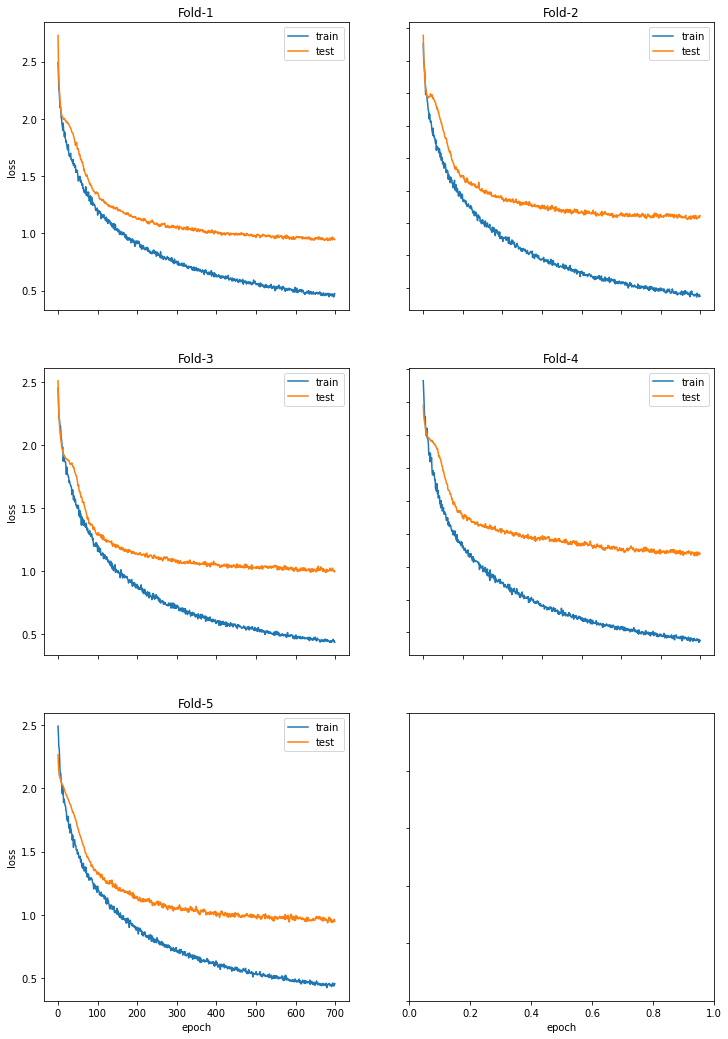

In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3, 2,figsize=(12,18))
axs[0, 0].plot(hist[0].history['loss'])
axs[0, 0].plot(hist[0].history['val_loss'])
axs[0, 0].set_title('Fold-1')
axs[0, 0].legend(['train', 'test'], loc='upper right')

axs[0, 1].plot(hist[1].history['loss'])
axs[0, 1].plot(hist[1].history['val_loss'])
axs[0, 1].set_title('Fold-2')
axs[0, 1].legend(['train', 'test'], loc='upper right')

axs[1, 0].plot(hist[2].history['loss'])
axs[1, 0].plot(hist[2].history['val_loss'])
axs[1, 0].set_title('Fold-3')
axs[1, 0].legend(['train', 'test'], loc='upper right')

axs[1, 1].plot(hist[3].history['loss'])
axs[1, 1].plot(hist[3].history['val_loss'])
axs[1, 1].set_title('Fold-4')
axs[1, 1].legend(['train', 'test'], loc='upper right')

axs[2, 0].plot(hist[4].history['loss'])
axs[2, 0].plot(hist[4].history['val_loss'])
axs[2, 0].set_title('Fold-5')
axs[2, 0].legend(['train', 'test'], loc='upper right')

#axs[2, 1].plot(hist[0].history['loss'])
#axs[2, 1].plot(hist[0].history['val_loss'])
#axs[2, 1].set_title('model loss')
#axs[2, 1].legend(['train', 'test'], loc='upper right')

for ax in axs.flat:
    ax.set(xlabel='epoch', ylabel='loss')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
#fig.savefig('ravdesMale_85Folds.png')